In [2]:
import numpy as np
from seaborn import kdeplot
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

In [3]:
output_root = "budget_results"
output_dir = os.path.join(output_root, "ode")
wd_nn_array = np.load(os.path.join(output_dir, "wd_nn_array_mean.npy"))
wd_mcmc_array = np.load(os.path.join(output_root, "wd_mcmc_array_mean.npy"))
wd_nn_std = np.load(os.path.join(output_dir, "wd_nn_array_std.npy"))
wd_mcmc_std = np.load(os.path.join(output_root, "wd_mcmc_array_std.npy"))

budget = 4 ** 8
conditioning_list = [4 ** i for i in range(9)]

In [4]:
wd_mcmc_array

array([0.00912056, 2.35255265, 2.00238233, 2.3769587 , 2.76518363,
       2.6724487 , 2.7847268 , 3.12433317, 3.38769377])

Text(0, 0.5, 'W2 Error')

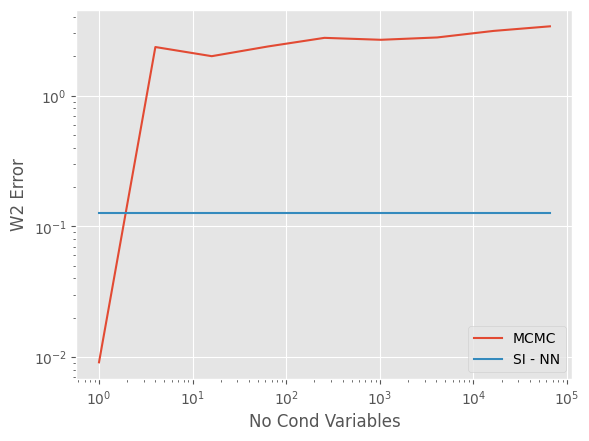

In [23]:
plt.plot(conditioning_list, wd_mcmc_array, label="MCMC")
plt.plot(conditioning_list, np.mean(wd_nn_array) * np.ones(9), label="SI - NN")
# plt.axhline(np.mean(wd_nn_array).item(), label="SI")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("No Cond Variables")
plt.ylabel("W2 Error")

In [7]:
np.mean(wd_nn_array)

np.float64(0.1264482132211623)

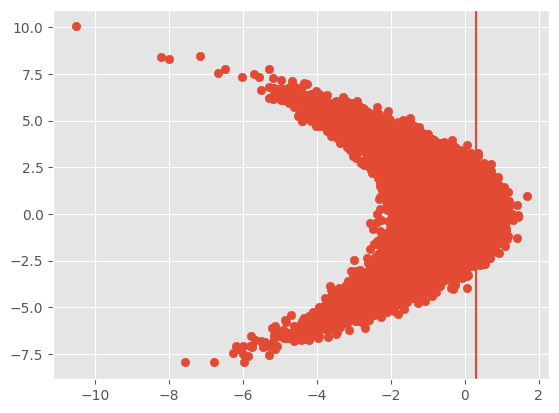

In [15]:
from triangular_transport.flows.methods.sampling import inf_train_gen
target_data = inf_train_gen(data="banana", rng=None, batch_size=budget)
plt.scatter(target_data[:, 0], target_data[:, 1])
plt.axvline(0.3)

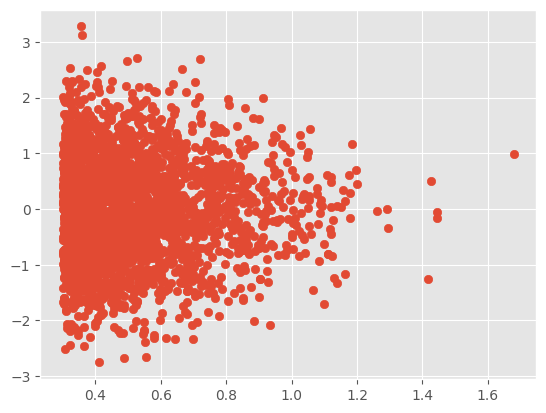

In [16]:
sub_data = target_data[np.where(target_data[:, 0] >= 0.3)[0]]
plt.scatter(sub_data[:, 0], sub_data[:, 1])

In [77]:
np.where(target_data[:, 0] >= 1.0)

(array([  200,  2304,  3889,  3964,  4859,  6934,  8541, 10894, 10989,
        11388, 11709, 13494, 15805, 16100, 16431, 17925, 18311, 19279,
        19826, 21210, 21255, 21778, 22481, 23786, 23842, 24328, 24884,
        25576, 26303, 26701, 30114, 30164, 30565, 31000, 31792, 32115,
        34320, 34836, 35196, 35322, 36159, 38090, 38249, 39510, 42396,
        43822, 46412, 46687, 46711, 46790, 47014, 48250, 48351, 49342,
        50649, 51254, 51893, 52166, 54206, 55660, 56929, 57522, 59152,
        60902, 61018, 62442, 62987, 63521]),)

In [76]:
np.max(target_data[:, 0])

np.float64(1.6780082795173554)

In [69]:
cond_vars[49]

np.float64(1.5765588923716285)

In [71]:
cond_vars[36]

np.float64(1.7298035568642156)